In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")
df.shape

(404290, 6)

In [3]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
353981,353981,195644,126593,Who is the worst Actor in Bollywood at present...,Who is the worst actor of Bollywood?,1
171576,171576,198049,89092,How is it possible to fall in love without fal...,"Can you be ""in love"" more than once?",0
223711,223711,66630,331600,What is the corporate culture like at Liberty ...,What is the corporate culture like at Excel Tr...,0
340618,340618,149556,468379,What are some things that neuroscientists know...,What are some things that you don't like that ...,0
341969,341969,57175,107328,Why are Indians not getting medals in Olympics?,What is the valid reason for India only gettin...,1
107694,107694,177119,177120,What are the benefits of recumbent exercise bike?,What are the physical benefits of an exercise ...,0
62675,62675,109202,109203,How can I memorize quickly?,What is the fastest way to memorize something?,1
241317,241317,200565,241534,What are some of the must-read books in Malaya...,What are some of the must read books in Malaya...,1
194571,194571,145613,294827,I want to stop playing Clash of Clans. What ca...,How many hours do you spend playing clash of c...,0
126833,126833,128483,204325,Have you ever been taken advantage of for your...,Has anyone taken advantage of your generosity?,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [5]:
# missing values
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [6]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

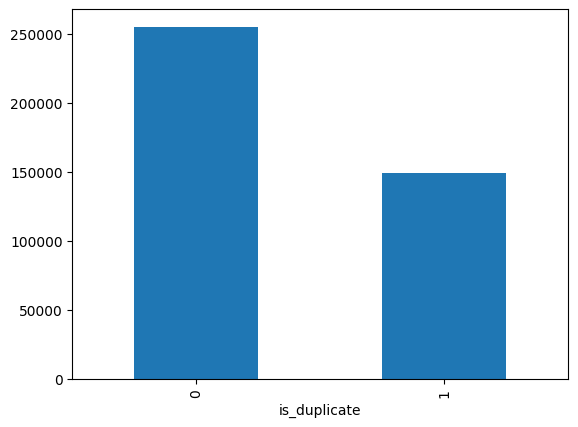

In [7]:
# Distribution of duplicate and non-duplicate questions

print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [8]:
# Repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 537933
Number of questions getting repeated 111780


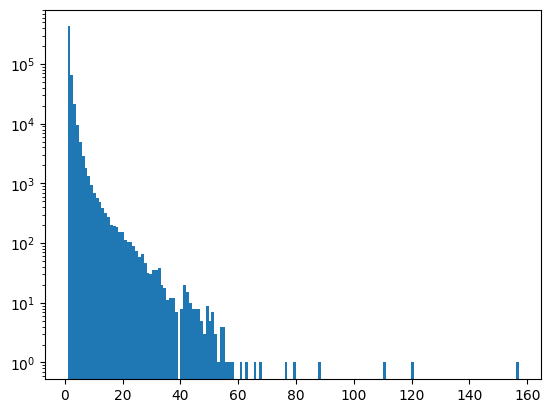

In [9]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [10]:
new_df = df.copy()

In [11]:
new_df['question1'] = new_df['question1'].fillna('')
new_df['question2'] = new_df['question2'].fillna('')

new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [12]:
ques_df = new_df[['question1','question2']]

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

questions = (
    ques_df['question1'].tolist()
    +
    ques_df['question2'].tolist()
)

cv = CountVectorizer(
    max_features=3000,
    dtype=np.uint8
)

X = cv.fit_transform(questions)

mid = len(ques_df)

q1_arr = X[:mid]
q2_arr = X[mid:]

In [14]:
from scipy.sparse import hstack

temp_df = hstack([q1_arr,q2_arr])

In [15]:
y = new_df['is_duplicate'].values

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    temp_df,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train,y_train)

y_pred = xgb.predict(X_test)

accuracy_score(y_test,y_pred)

0.7600979494917015

In [19]:
!brew install libomp

⠋ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠋ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠙ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠙ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠚ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠚ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠞ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠞ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠖ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠖ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠦ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠦ JSON API packages.arm64_sequoia.jws.json           Downloading  15.2MB/-------⠴ JSON API packages.arm64_sequoia.jws.js

In [20]:
from xgboost import XGBClassifier
print("XGBoost working")

XGBoost working


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.7394073561057657


In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train,y_train)

y_pred = xgb.predict(X_test)

accuracy_score(y_test,y_pred)

0.7600979494917015

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

questions = (
    ques_df['question1'].tolist()
    +
    ques_df['question2'].tolist()
)

cv = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = cv.fit_transform(questions)

mid = len(ques_df)

q1_arr = X[:mid]
q2_arr = X[mid:]

In [27]:
from scipy.sparse import hstack

temp_df = hstack([q1_arr, q2_arr])

In [28]:
y = new_df['is_duplicate'].values

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    temp_df,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7398278463479185


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.94      0.82     51005
           1       0.79      0.40      0.53     29853

    accuracy                           0.74     80858
   macro avg       0.76      0.67      0.68     80858
weighted avg       0.75      0.74      0.71     80858



In [36]:
new_df['question1'] = new_df['question1'].fillna('')
new_df['question2'] = new_df['question2'].fillna('')

new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [37]:
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [38]:
new_df['q1_num_words'] = new_df['question1'].str.split().str.len()

new_df['q2_num_words'] = new_df['question2'].str.split().str.len()

In [39]:
def common_words(row):

    w1 = set(map(
        lambda word: word.lower().strip(),
        row['question1'].split(" ")
    ))

    w2 = set(map(
        lambda word: word.lower().strip(),
        row['question2'].split(" ")
    ))

    return len(w1 & w2)

In [40]:
new_df['word_common'] = new_df.apply(
    common_words,
    axis=1
)

In [41]:
def total_words(row):

    w1 = set(map(
        lambda word: word.lower().strip(),
        row['question1'].split(" ")
    ))

    w2 = set(map(
        lambda word: word.lower().strip(),
        row['question2'].split(" ")
    ))

    return (len(w1) + len(w2))

In [42]:
new_df['word_total'] = new_df.apply(
    total_words,
    axis=1
)

In [34]:
new_df['word_share'] = np.round(
    new_df['word_common'] /
    np.where(new_df['word_total']==0,1,new_df['word_total']),
    2
)

minimum characters 0
maximum characters 623
average num of characters 59


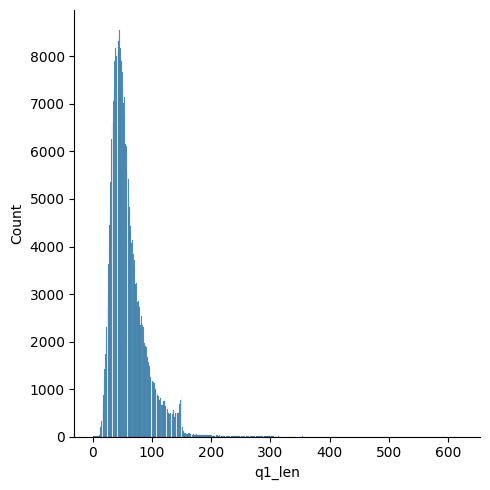

In [35]:
sns.displot(new_df['q1_len'])

print('minimum characters', new_df['q1_len'].min())
print('maximum characters', new_df['q1_len'].max())
print('average num of characters', int(new_df['q1_len'].mean()))

minimum characters 0
maximum characters 1169
average num of characters 60


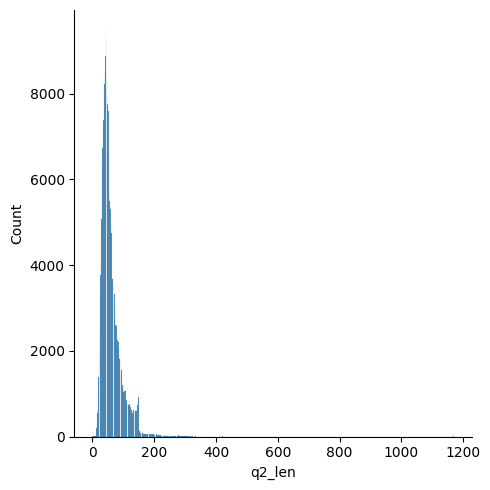

In [36]:
sns.displot(new_df['q2_len'])

print('minimum characters', new_df['q2_len'].min())
print('maximum characters', new_df['q2_len'].max())
print('average num of characters', int(new_df['q2_len'].mean()))

minimum words 0
maximum words 125
average num of words 10


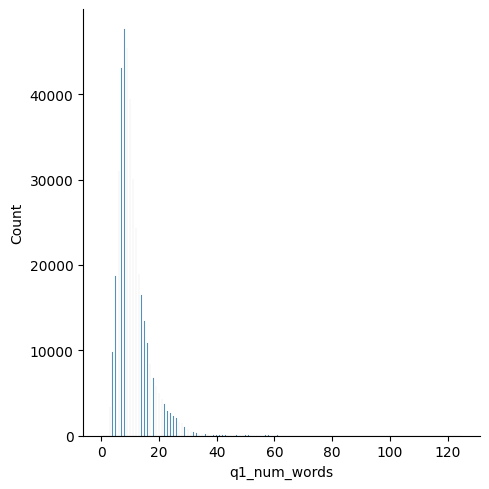

In [37]:
sns.displot(new_df['q1_num_words'])

print('minimum words', new_df['q1_num_words'].min())
print('maximum words', new_df['q1_num_words'].max())
print('average num of words', int(new_df['q1_num_words'].mean()))

minimum words 0
maximum words 237
average num of words 11


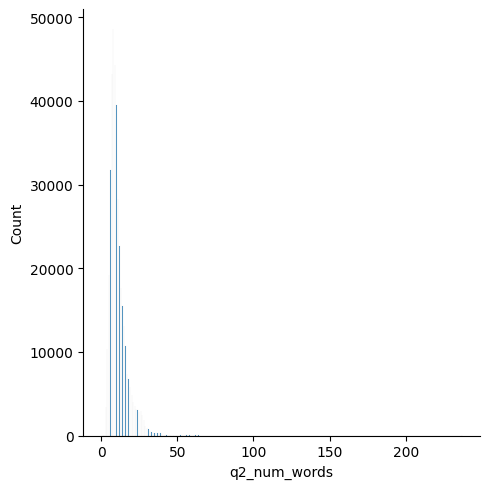

In [38]:
sns.displot(new_df['q2_num_words'])

print('minimum words', new_df['q2_num_words'].min())
print('maximum words', new_df['q2_num_words'].max())
print('average num of words', int(new_df['q2_num_words'].mean()))

/var/folders/g8/0_glzn0j1c15t6h96jvxw4v80000gn/T/ipykernel_12158/847226910.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
/var/folders/g8/0_glzn0j1c15t6h96jvxw4v80000gn/T/ipykernel_12158/847226910.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

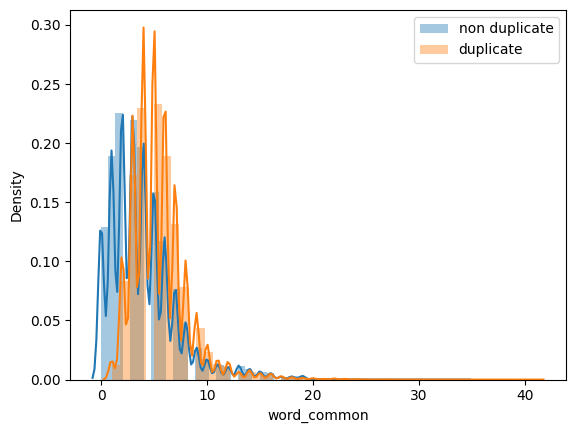

In [39]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

/var/folders/g8/0_glzn0j1c15t6h96jvxw4v80000gn/T/ipykernel_12158/590203201.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'],label='non duplicate')
/var/folders/g8/0_glzn0j1c15t6h96jvxw4v80000gn/T/ipykernel_12158/590203201.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad

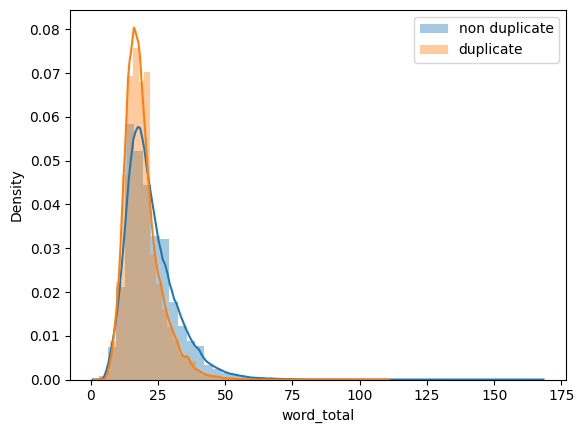

In [40]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

/var/folders/g8/0_glzn0j1c15t6h96jvxw4v80000gn/T/ipykernel_12158/2292000331.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
/var/folders/g8/0_glzn0j1c15t6h96jvxw4v80000gn/T/ipykernel_12158/2292000331.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457

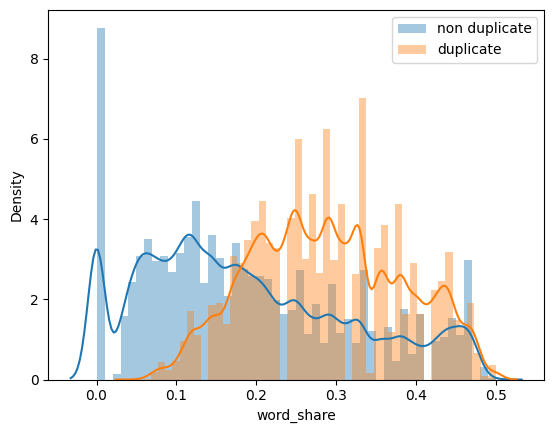

In [41]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [43]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?


In [44]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])

print(final_df.shape)

final_df.head()

(404290, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,0,66,57,14,12,10,23,0.43
1,0,51,88,8,13,4,20,0.20
2,0,73,59,14,10,4,24,0.17
3,0,50,65,11,9,0,19,0.00
4,0,76,39,13,7,2,20,0.10


In [45]:
from sklearn.feature_extraction.text import CountVectorizer

questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=5000)

q1_arr, q2_arr = np.vsplit(
    cv.fit_transform(questions).toarray(),
    2
)

In [ ]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape